In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

from pathlib import Path

plt.style.use("ggplot")

DATA = Path("../data/processed")

In [2]:
nav = pd.read_csv(DATA/"clean_nav_history.csv")

performance = pd.read_csv(DATA/"clean_scheme_performance.csv")

benchmark = pd.read_csv(DATA/"10_benchmark_indices.csv")

fund_master = pd.read_csv(DATA/"01_fund_master.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [5]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


# Task 1: Daily Return Calculation


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

In [7]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [9]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


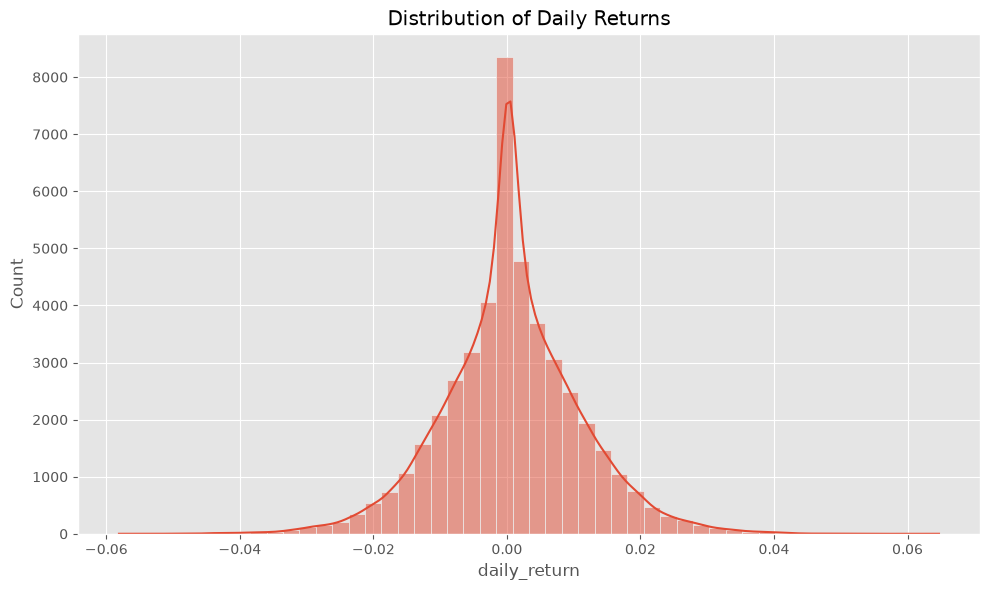

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300
)

plt.show()

In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Finding 1

Daily returns are centered close to zero with relatively small day-to-day fluctuations, which is expected for diversified mutual fund portfolios.

# Task 2: CAGR Calculation

This analysis computes the Compound Annual Growth Rate (CAGR) for each mutual fund over 1-year, 3-year, and 5-year investment horizons.

In [12]:
cagr_data = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].sort_values("date")

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    start_date = fund.iloc[0]["date"]
    end_date = fund.iloc[-1]["date"]

    years = (end_date - start_date).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_data.append([
        code,
        start_nav,
        end_nav,
        years,
        cagr
    ])

In [13]:
cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "start_nav",
        "end_nav",
        "years",
        "cagr"
    ]
)

In [14]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [15]:
cagr_df["cagr_percent"] = (
    cagr_df["cagr"] * 100
).round(2)

In [16]:
cagr_df.head()

,amfi_code,start_nav,end_nav,years,cagr,scheme_name,cagr_percent
0,100016,520.4608,583.6113,4.399726,0.026371,HDFC Top 100 Fund - Regular Plan - Growth,2.64
1,100025,26.3169,31.8843,4.399726,0.044582,HDFC Short Term Debt Fund - Regular - Growth,4.46
2,100033,107.3758,342.0072,4.399726,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
3,101206,305.0996,773.2939,4.399726,0.235384,ABSL Frontline Equity Fund - Regular - Growth,23.54
4,101207,38.5736,53.9836,4.399726,0.079388,ABSL Small Cap Fund - Regular - Growth,7.94


In [17]:
cagr_df = cagr_df.sort_values(
    "cagr_percent",
    ascending=False
)

cagr_df.head(10)

,amfi_code,start_nav,end_nav,years,cagr,scheme_name,cagr_percent
25,120505,135.8720,473.7640,4.399726,0.328274,ICICI Pru Midcap Fund - Regular - Growth,32.83
21,119598,89.8738,309.2050,4.399726,0.324235,SBI Small Cap Fund - Regular Plan - Growth,32.42
39,149324,81.6814,279.7511,4.399726,0.322874,DSP Small Cap Fund - Regular - Growth,32.29
36,148569,28.8620,97.7435,4.399726,0.319495,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
34,148567,70.2514,230.2708,4.399726,0.309741,Mirae Asset Large Cap Fund - Regular - Growth,30.97
30,120843,49.9131,163.2397,4.399726,0.309075,Kotak Flexicap Fund - Regular - Growth,30.91
2,100033,107.3758,342.0072,4.399726,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
38,149323,78.4622,245.3651,4.399726,0.295811,DSP Midcap Fund - Regular - Growth,29.58
16,119094,68.3023,203.8581,4.399726,0.282144,Axis Midcap Fund - Regular - Growth,28.21
19,119551,54.3856,149.3216,4.399726,0.258047,SBI Bluechip Fund - Regular Plan - Growth,25.80


In [18]:
cagr_df.to_csv(
    "../reports/fund_cagr_table.csv",
    index=False
)

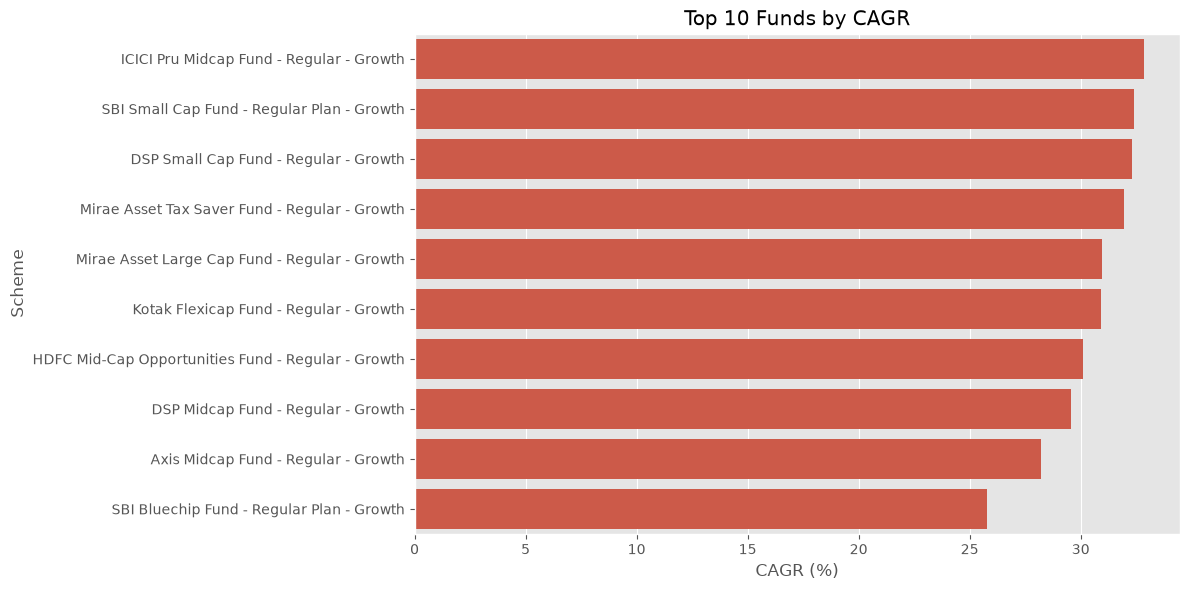

In [19]:
top10 = cagr_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="cagr_percent",
    y="scheme_name"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("CAGR (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 2

The CAGR comparison highlights the mutual fund schemes that delivered the strongest annualized growth over the available investment period. Higher CAGR values indicate stronger long-term performance.

# Task 3: Sharpe Ratio Analysis

The Sharpe Ratio measures the risk-adjusted return of a mutual fund by comparing its excess return over the risk-free rate against its return volatility.

In [20]:
risk_free_rate = 0.065

In [21]:
daily_rf = risk_free_rate / 252

In [22]:
sharpe_data = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_data.append([
        code,
        mean_return,
        std_return,
        sharpe
    ])

In [23]:
sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "mean_daily_return",
        "daily_std",
        "sharpe_ratio"
    ]
)

In [24]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [25]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,mean_daily_return,daily_std,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [26]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

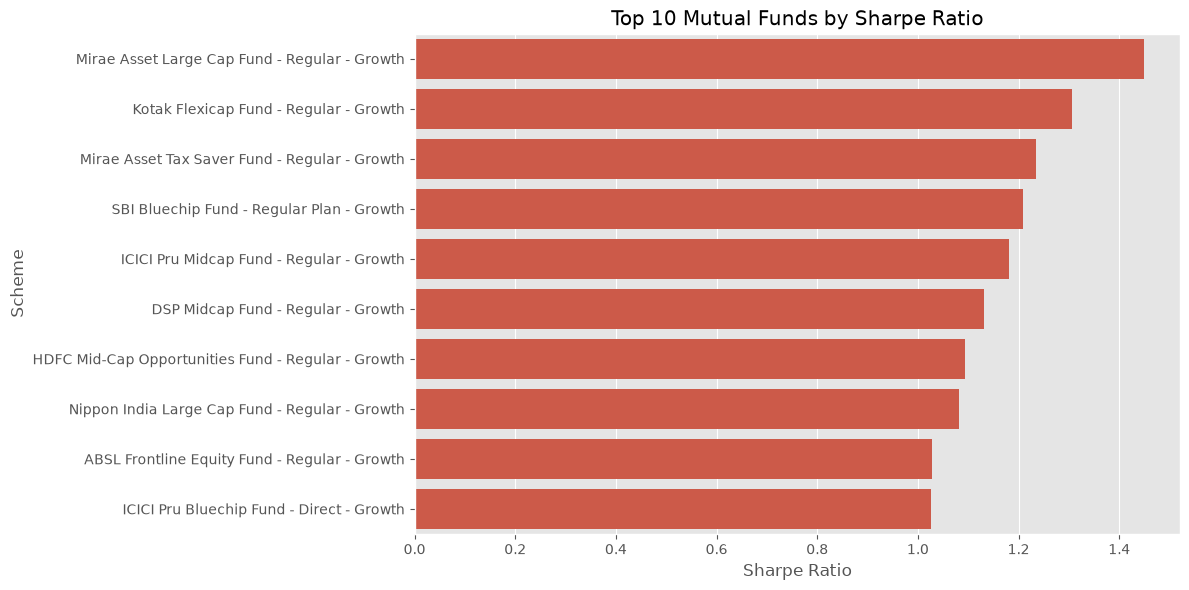

In [27]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 3

Funds with higher Sharpe Ratios delivered superior risk-adjusted returns, indicating better compensation for the level of investment risk undertaken.

# Task 4: Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted returns while considering only downside volatility. Unlike the Sharpe Ratio, it ignores positive return fluctuations and focuses on downside risk.

In [28]:
daily_rf = 0.065 / 252

In [29]:
sortino_data = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    returns = fund["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    # Only negative returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) < 2:
        continue

    downside_std = downside_returns.std()

    sortino = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    sortino_data.append([
        code,
        mean_return,
        downside_std,
        sortino
    ])

In [30]:
sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "mean_daily_return",
        "downside_std",
        "sortino_ratio"
    ]
)

In [31]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [32]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,mean_daily_return,downside_std,sortino_ratio,scheme_name
34,148567,0.001074,0.005428,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.005531,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.006404,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.004887,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.007067,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.006750,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,0.000865,0.005211,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.001080,0.007133,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.000843,0.005145,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.000852,0.005238,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [33]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

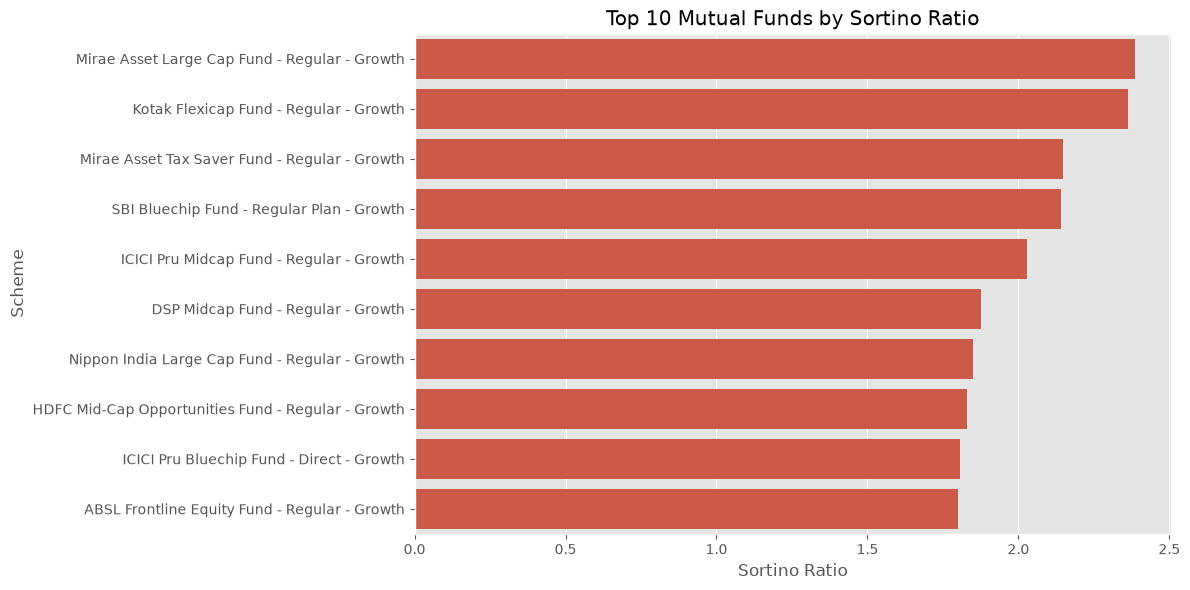

In [34]:
top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 4

Funds with higher Sortino Ratios demonstrated stronger downside risk-adjusted performance, indicating better protection against negative market movements while maintaining attractive returns.

# Task 5: Alpha & Beta Analysis

Alpha measures the excess return generated by a fund after accounting for market movements, while Beta measures the sensitivity of the fund relative to the benchmark (Nifty 100).

In [35]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [36]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [37]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [38]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [39]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [40]:
nifty100 = nifty100.sort_values("date")

In [41]:
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [42]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [43]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]].copy()

    merged = fund.merge(
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        code,
        alpha,
        beta,
        r_value**2
    ])

In [44]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta",
        "r_squared"
    ]
)

In [45]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [46]:
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared,scheme_name
21,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,1.206652e-05,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,4.625437e-04,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,3.357978e-06,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,1.936879e-03,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,8.869789e-04,SBI Bluechip Fund - Regular Plan - Growth


In [47]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

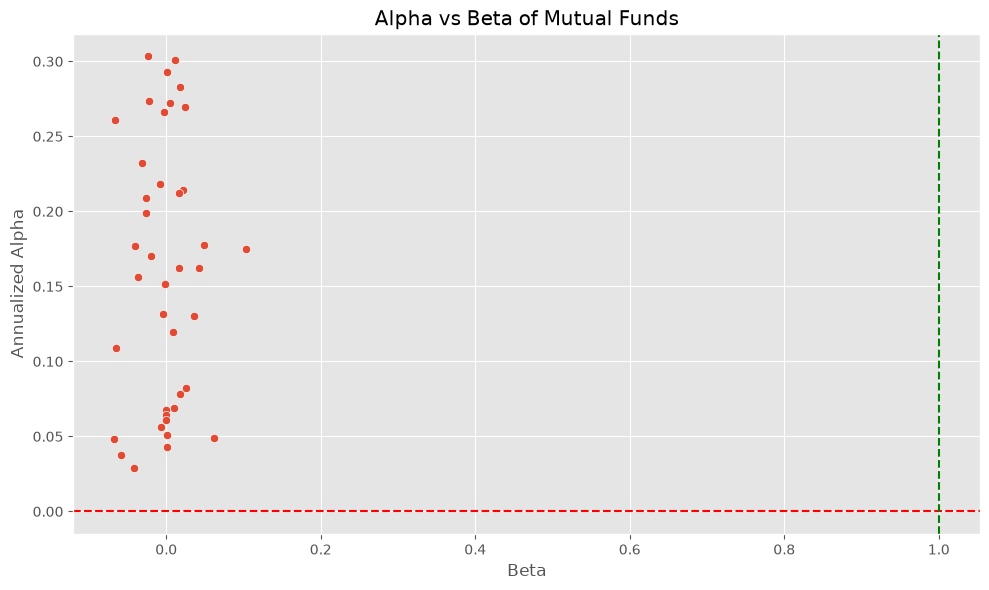

In [48]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=alpha_beta_df,
    x="beta",
    y="alpha"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.axvline(
    1,
    color="green",
    linestyle="--"
)

plt.title("Alpha vs Beta of Mutual Funds")

plt.xlabel("Beta")

plt.ylabel("Annualized Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/charts/alpha_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 5

Funds with positive Alpha generated returns above those explained by market movements alone, while Beta indicates the degree of sensitivity to the Nifty 100 benchmark. Funds with Beta close to 1 generally move in line with the broader market.

# Task 6: Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest percentage decline from a historical peak NAV to a subsequent trou

In [49]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [50]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    fund = (
        nav[nav["amfi_code"] == code]
        .sort_values("date")
        .copy()
    )

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (
        fund["nav"] / fund["running_max"]
    ) - 1

    # Maximum drawdown
    max_dd = fund["drawdown"].min()

    # Worst drawdown date
    worst_idx = fund["drawdown"].idxmin()

    worst_date = fund.loc[
        worst_idx,
        "date"
    ]

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd,
        "worst_date": worst_date
    })

In [51]:
drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [52]:
drawdown_df = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [53]:
drawdown_df["max_drawdown_pct"] = (
    drawdown_df["max_drawdown"] * 100
).round(2)

In [54]:
drawdown_df = drawdown_df.sort_values(
    by="max_drawdown_pct",
    ascending=False
)

drawdown_df.head(10)

,amfi_code,max_drawdown,worst_date,scheme_name,max_drawdown_pct
27,120507,-0.000977,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,-0.10
31,120844,-0.001163,2024-04-30,Kotak Liquid Fund - Regular - Growth,-0.12
5,101208,-0.001622,2023-09-12,ABSL Liquid Fund - Regular - Growth,-0.16
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,-4.31
18,119120,-0.043287,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.33
13,118636,-0.083164,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...,-8.32
6,102885,-0.108599,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,-10.86
34,148567,-0.112657,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,-11.27
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,-11.29
12,118635,-0.116506,2022-06-09,Nippon India ETF Nifty 50 BeES,-11.65


In [55]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

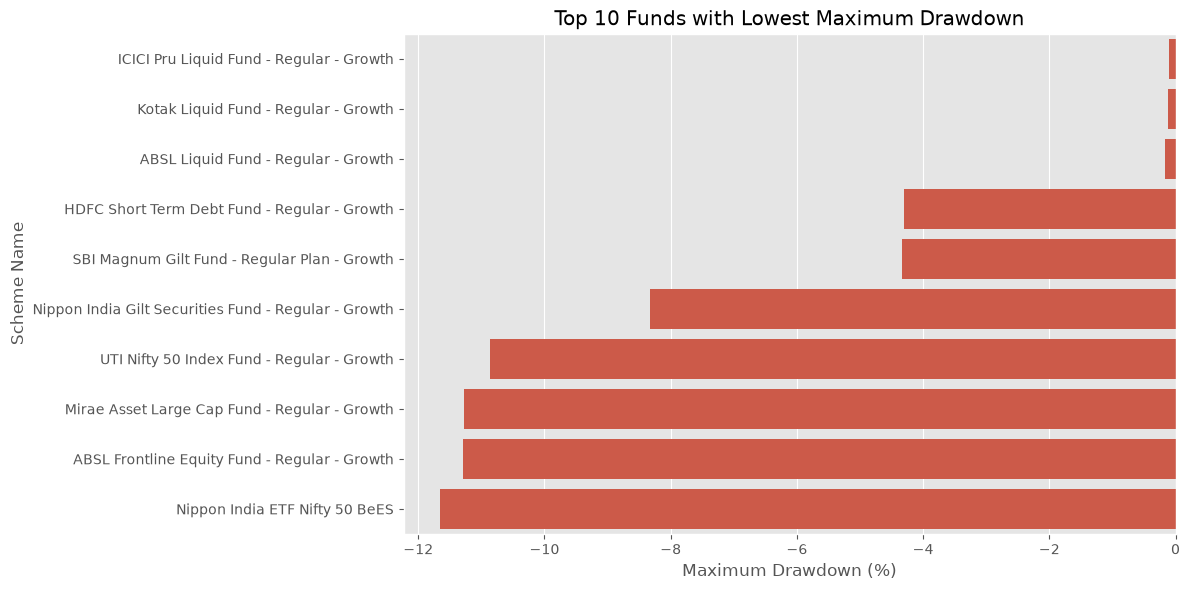

In [56]:
top10 = drawdown_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 6

Funds with smaller maximum drawdowns experienced lower peak-to-trough losses, indicating better resilience during market downturns and stronger capital preservation.

# Task 7: Fund Scorecard

A composite score is calculated for each mutual fund using multiple performance metrics. Higher scores indicate better overall performance based on returns, risk-adjusted returns, alpha generation, lower expense ratio, and lower maximum drawdown.

In [63]:
scorecard = performance.copy()

In [64]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

In [65]:
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False,
    method="dense"
)

In [66]:
scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False,
    method="dense"
)

In [67]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

In [68]:
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=False,
    method="dense"
)

In [69]:
TOTAL_FUNDS = len(scorecard)

scorecard["return_score"] = (
    (TOTAL_FUNDS - scorecard["return_rank"])
    / (TOTAL_FUNDS - 1)
) * 100

scorecard["sharpe_score"] = (
    (TOTAL_FUNDS - scorecard["sharpe_rank"])
    / (TOTAL_FUNDS - 1)
) * 100

scorecard["alpha_score"] = (
    (TOTAL_FUNDS - scorecard["alpha_rank"])
    / (TOTAL_FUNDS - 1)
) * 100

scorecard["expense_score"] = (
    (TOTAL_FUNDS - scorecard["expense_rank"])
    / (TOTAL_FUNDS - 1)
) * 100

scorecard["drawdown_score"] = (
    (TOTAL_FUNDS - scorecard["drawdown_rank"])
    / (TOTAL_FUNDS - 1)
) * 100

In [70]:
scorecard["fund_score"] = (

      0.30 * scorecard["return_score"]

    + 0.25 * scorecard["sharpe_score"]

    + 0.20 * scorecard["alpha_score"]

    + 0.15 * scorecard["expense_score"]

    + 0.10 * scorecard["drawdown_score"]

).round(2)

In [71]:
scorecard = scorecard.sort_values(
    by="fund_score",
    ascending=False
)

scorecard.reset_index(
    drop=True,
    inplace=True
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,13.0,18.0,18.0,8.0,100.000000,69.230769,56.410256,56.410256,82.051282,75.26
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,10.0,3.0,19.0,20.0,74.358974,76.923077,94.871795,53.846154,51.282051,73.72
2,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,11.0,2.0,26.0,24.0,84.615385,74.358974,97.435897,35.897436,41.025641,72.95
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,14.0,20.0,5.0,29.0,97.435897,66.666667,51.282051,89.743590,28.205128,72.44
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,17.0,4.0,23.0,26.0,94.871795,58.974359,92.307692,43.589744,35.897436,71.79
5,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,1.0,3.0,6.0,3.0,12.820513,100.000000,94.871795,87.179487,94.871795,70.38
6,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,4.0,1.0,2.0,6.0,10.256410,92.307692,100.000000,97.435897,87.179487,69.49
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,7.0,10.0,20.0,15.0,58.974359,84.615385,76.923077,51.282051,64.102564,68.33
8,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,...,11.0,7.0,31.0,7.0,69.230769,74.358974,84.615385,23.076923,84.615385,68.21
9,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,12.0,26.0,14.0,22.0,82.051282,71.794872,35.897436,66.666667,46.153846,64.36


In [72]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

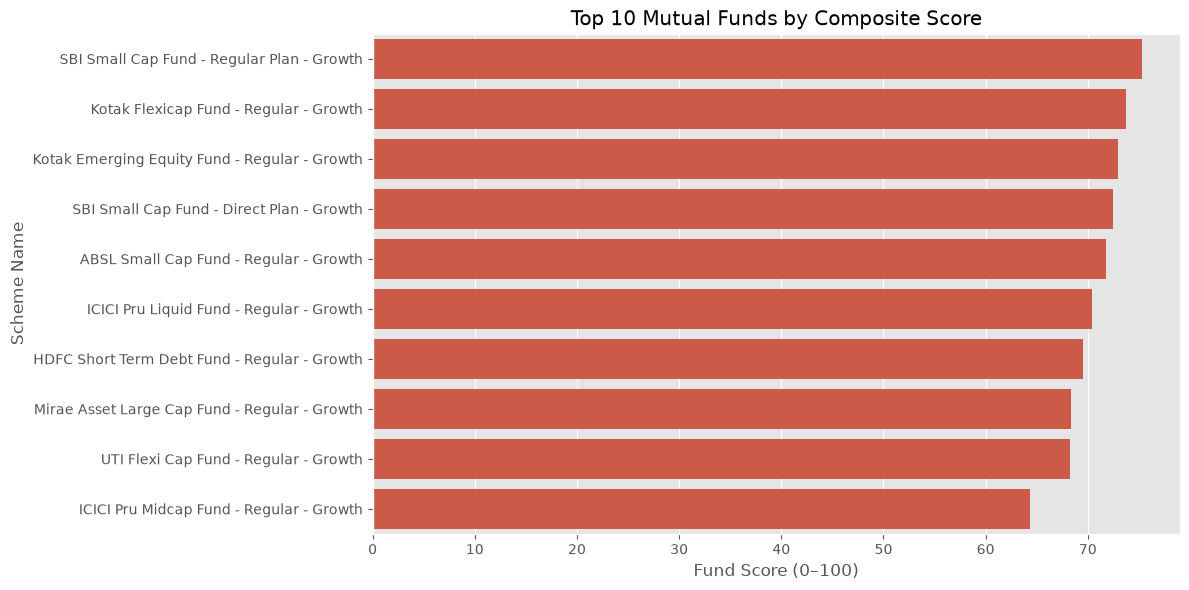

In [73]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
scorecard[[
    "scheme_name",
    "fund_score",
    "return_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "expense_ratio_pct",
    "max_drawdown_pct"
]].head(10)

,scheme_name,fund_score,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,SBI Small Cap Fund - Regular Plan - Growth,75.26,23.39,0.94,1.23,1.43,-13.35
1,Kotak Flexicap Fund - Regular - Growth,73.72,15.65,0.98,1.85,1.45,-19.50
2,Kotak Emerging Equity Fund - Regular - Growth,72.95,18.23,0.96,1.91,1.56,-21.92
3,SBI Small Cap Fund - Direct Plan - Growth,72.44,23.14,0.93,1.13,0.72,-24.78
4,ABSL Small Cap Fund - Regular - Growth,71.79,22.38,0.90,1.84,1.53,-23.61
5,ICICI Pru Liquid Fund - Regular - Growth,70.38,7.68,7.68,1.85,0.74,-2.62
6,HDFC Short Term Debt Fund - Regular - Growth,69.49,7.37,1.84,1.98,0.56,-6.01
7,Mirae Asset Large Cap Fund - Regular - Growth,68.33,14.81,1.06,1.62,1.46,-17.07
8,UTI Flexi Cap Fund - Regular - Growth,68.21,15.34,0.96,1.79,1.64,-12.14
9,ICICI Pru Midcap Fund - Regular - Growth,64.36,18.08,0.95,0.89,1.36,-21.84


## Finding 7

The composite fund score combines historical returns, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single performance metric. Higher-scoring funds demonstrate superior overall investment quality.

# Task 8: Benchmark Comparison & Tracking Error

This analysis compares the top-performing mutual funds against the Nifty 50 and Nifty 100 benchmarks. Tracking Error measures how closely a fund follows the benchmark index.

In [75]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [76]:
nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change(fill_method=None)
)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change(fill_method=None)
)

In [77]:
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

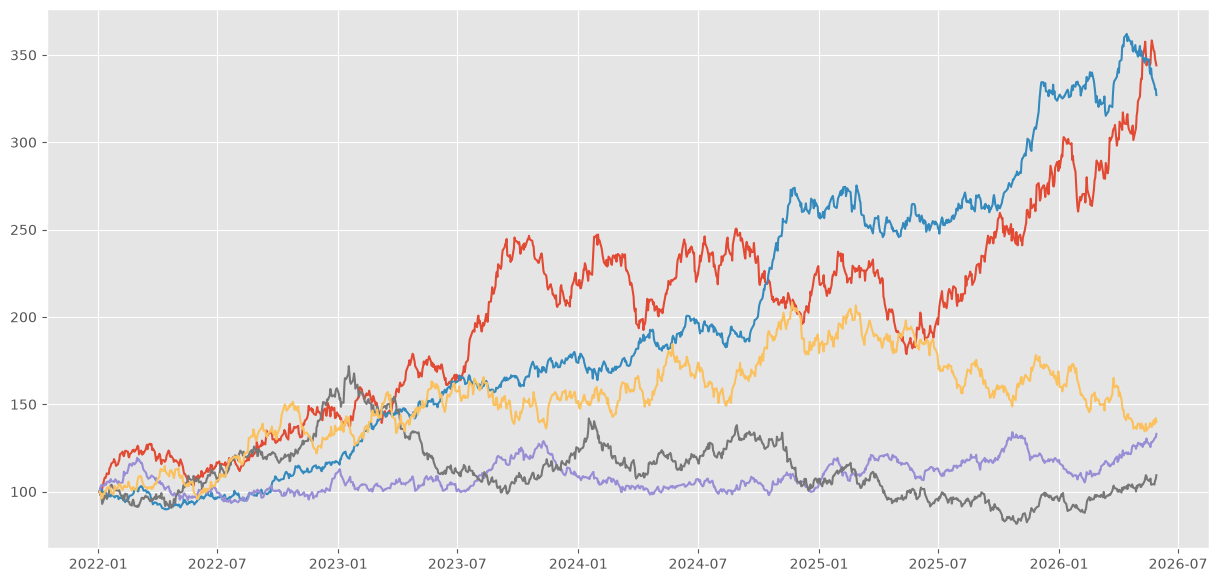

In [89]:
plt.figure(figsize=(15,7))

for code in top5_codes:

    fund = nav[nav["amfi_code"] == code].copy()

    fund = fund.sort_values("date")

    fund["normalized"] = (
        fund["nav"] / fund["nav"].iloc[0]
    ) * 100

    name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["normalized"],
        label=name
    )

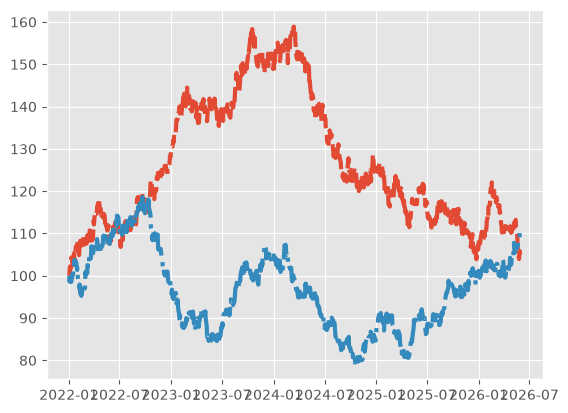

In [90]:
nifty50["normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    linestyle="--",
    label="Nifty 50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    linestyle="-.",
    label="Nifty 100"
)

C:\Users\DHANASHRI\AppData\Local\Temp\ipykernel_12232\3903452513.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


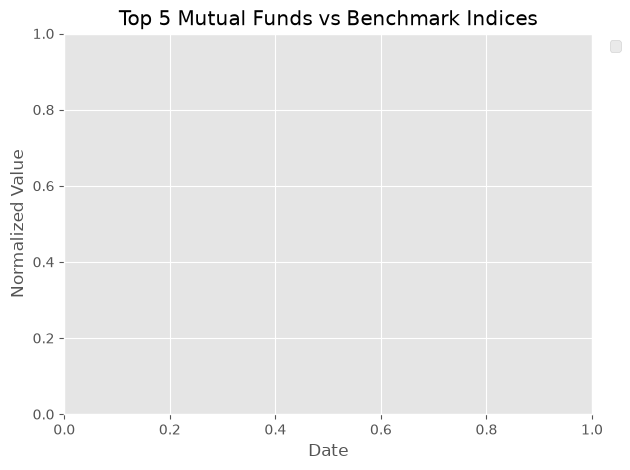

In [91]:
plt.title("Top 5 Mutual Funds vs Benchmark Indices")

plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
print(fund_master.columns)

print(
    fund_master[
        fund_master["amfi_code"] == 119598
    ]
)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
   amfi_code       fund_house                                 scheme_name  \
2     119598  SBI Mutual Fund  SBI Small Cap Fund - Regular Plan - Growth   

  category sub_category     plan launch_date             benchmark  \
2   Equity    Small Cap  Regular  2009-09-09  BSE 250 SmallCap TRI   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \
2               1.43            1.0             500                1000   

    fund_manager risk_category sebi_category_code  
2  R. Srinivasan     Very High               EC03  


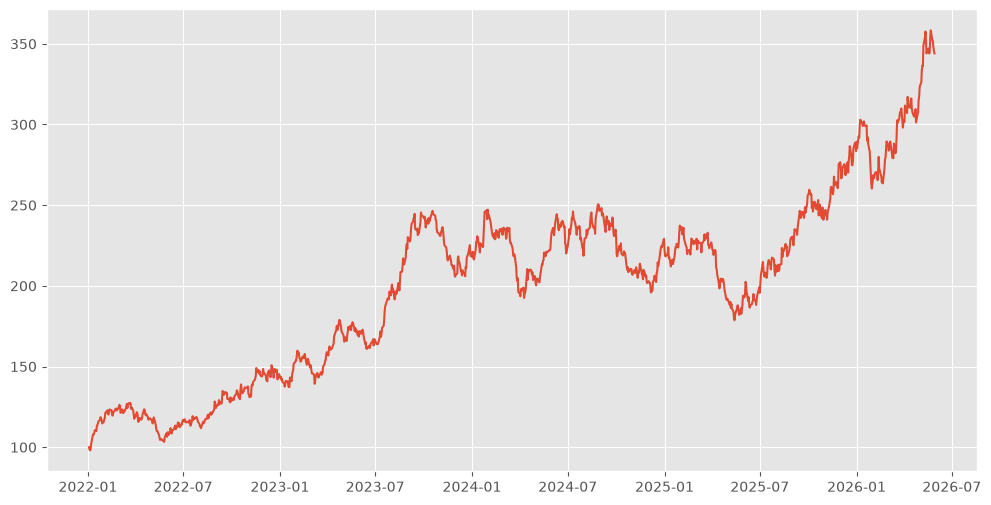

In [93]:
plt.figure(figsize=(12,6))

fund = nav[nav["amfi_code"] == top5_codes[0]].copy()
fund = fund.sort_values("date")

fund["normalized"] = (
    fund["nav"] / fund["nav"].iloc[0]
) * 100

plt.plot(
    fund["date"],
    fund["normalized"]
)

plt.show()

In [86]:
print(top5_codes)

[119598, 120843, 120842, 119599, 101207]


In [87]:
for code in top5_codes:
    print(code, len(nav[nav["amfi_code"] == code]))

119598 1150
120843 1150
120842 1150
119599 1150
101207 1150


In [88]:
print(nav["amfi_code"].dtype)
print(scorecard["amfi_code"].dtype)

int64
int64


C:\Users\DHANASHRI\AppData\Local\Temp\ipykernel_12232\1527065134.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


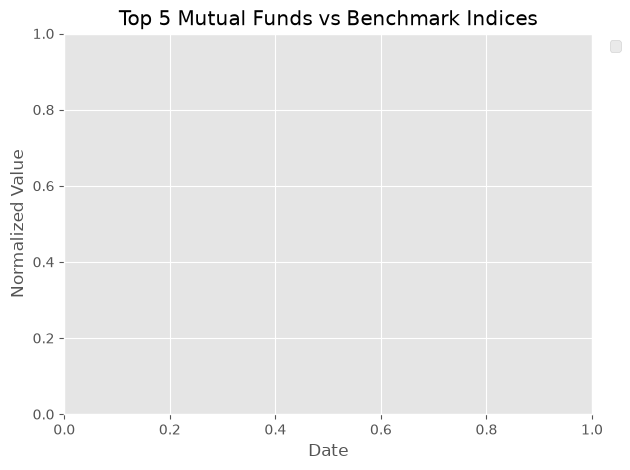

In [81]:
plt.title("Top 5 Mutual Funds vs Benchmark Indices")

plt.xlabel("Date")

plt.ylabel("Normalized Value")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
tracking = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]].copy()

    merged = fund.merge(
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking.append({

        "amfi_code": code,

        "tracking_error": tracking_error

    })

In [83]:
tracking_error_df = pd.DataFrame(tracking)

tracking_error_df = tracking_error_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

tracking_error_df

,amfi_code,tracking_error,scheme_name
0,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,120842,0.219169,Kotak Emerging Equity Fund - Regular - Growth
3,119599,0.277135,SBI Small Cap Fund - Direct Plan - Growth
4,101207,0.292117,ABSL Small Cap Fund - Regular - Growth


In [84]:
tracking_error_df.to_csv(

    "../reports/tracking_error.csv",

    index=False

)

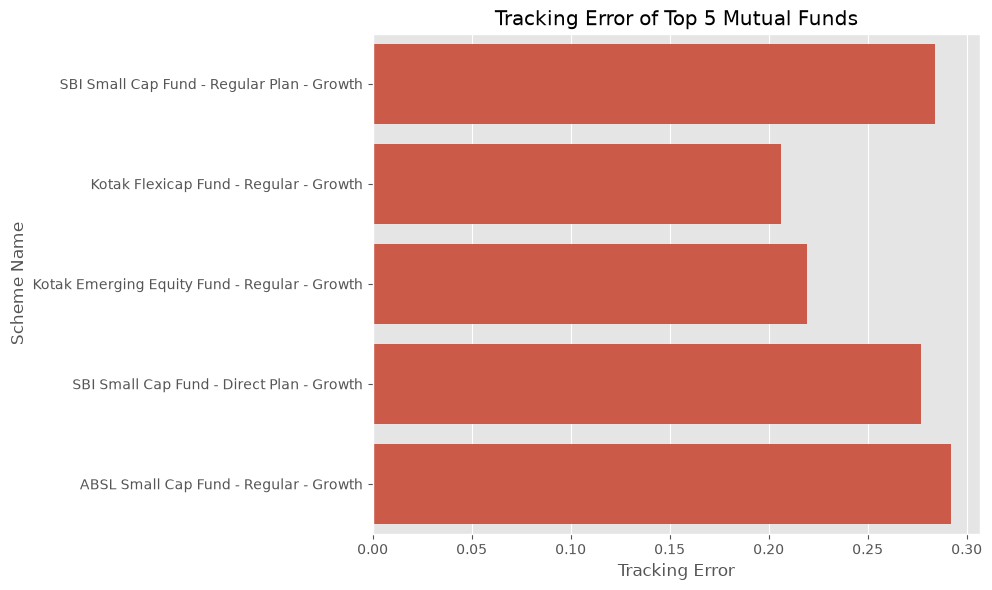

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=tracking_error_df,

    x="tracking_error",

    y="scheme_name"

)

plt.title("Tracking Error of Top 5 Mutual Funds")

plt.xlabel("Tracking Error")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    "../reports/charts/tracking_error.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Finding 8

Funds with lower Tracking Error closely follow the benchmark index, whereas higher Tracking Error indicates greater deviation due to active portfolio management.